# Training a Neural Estimator for Simulated Spatio-Temporal SST-like Fields

This notebook assumes that the preprocessing pipeline has already been executed.
In this notebook, we train a neural estimator to infer the parameters of a spatio-temporal Gaussian Random Field (GRF)  from simulated SST-like spatio-temporal fields.

The overall project is based on simulation-based inference, where neural networks are used to learn the mapping from simulated observations to the underlying parameters that generated them. Here, the goal is to estimate the two main parameters controlling the spatio-temporal dependence structure:

- **θ₁**: the spatial range parameter in the Matérn covariance model
- **θ₂**: the temporal dependence parameter in the AR(1) process

The training data were generated in the preprocessing stage and split into training, validation, and test sets.
After preprocessing, each sample has a fixed input shape suitable for baseline estimator training.

This notebook focuses on the following steps:

1. Loading the processed datasets
2. Inspecting data dimensions and structure
3. Setting up GPU-enabled training
4. Defining the neural estimator architecture
5. Training the model for up to 100 epochs with early stopping
6. Monitoring validation performance
7. Preparing the trained estimator for downstream evaluation

The training pipeline is implemented in Julia using `NeuralEstimators.jl`, together with `Flux.jl` and `CUDA.jl` for neural network training and GPU acceleration.

## Training-Ready Processed Data

The simulation and preprocessing pipeline was completed in the previous notebook.

After first-order temporal differencing and conservative temporal truncation, all samples were standardized to a fixed shape of `(21, 21, 1, 9)`.

This provides a standardized input representation that can be used directly for estimator training without additional preprocessing in this notebook.

The processed datasets are loaded here in their training-ready baseline format, together with their corresponding parameter matrices.


## Environment and Software Dependencies

### System Configuration
| Component | Details |
| :--- | :--- |
| **OS** | Windows 11 |
| **GPU** | NVIDIA RTX 4070 Laptop |
| **Julia** | v1.12 |
| **CUDA Toolkit** | Version compatible with installed NVIDIA driver |

---

### Core Packages

The following Julia packages are used in this notebook:

- `CUDA.jl` — Enables GPU acceleration for training and tensor operations.
- `Flux.jl` — Core deep learning framework used for building neural networks.
- `NeuralEstimators.jl` — Framework for simulation-based neural inference.
- `JLD2.jl` — Efficient loading of pre-generated simulation datasets.
- `Statistics` — Used for normalization and data preprocessing.
- `Random` — Ensures reproducibility through controlled random seeds.

---

### Environment Setup

This project uses a dedicated Julia environment defined by `Project.toml` and `Manifest.toml` for reproducible package resolution.

To ensure reproducibility, the environment is activated and instantiated at the start of the notebook:

```julia
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

In [1]:
using Pkg

# Activate the project environment
Pkg.activate(joinpath(@__DIR__, ".."))

# Instantiate all required dependencies
Pkg.instantiate()

  Activating project at `c:\Users\wejda\Documents\NBE`


In [2]:
# Import core packages for data loading, neural modeling, and GPU training

using JLD2
using Statistics
using Random

using Flux
using CUDA
using cuDNN
using NeuralEstimators

┌ Error: You are using CUDA 13.0.0, but CUDA.jl was precompiled for CUDA 13.2.0.
│ This is unexpected; please file an issue.
└ @ CUDA C:\Users\wejda\.julia\packages\CUDA\Il00B\src\initialization.jl:148


In [3]:
# ================================
# Verify CUDA availability
# ================================

println("CUDA functional: ", CUDA.functional())
println("GPU: ", CUDA.name(CUDA.device()))

CUDA functional: true
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
using Random

# Ensure reproducibility across runs
Random.seed!(42)

TaskLocalRNG()

## Processed Dataset Summary

The training notebook uses the processed datasets generated in the preprocessing stage.

Three dataset splits are loaded:

- **Training set:** 10,000 samples
- **Validation set:** 1,000 samples
- **Test set:** 500 samples

Each simulated observation is stored as a 4D tensor:

`(21, 21, 1, 9)`

where:

- `21 × 21` corresponds to the spatial grid,
- `1` is the channel dimension,
- `9` is the fixed temporal length after first-order differencing and conservative temporal truncation.

The target parameters are stored separately in matrices of shape `(2, N)`, where each column contains the two ground-truth parameters associated with one simulated sample:

- **θ₁**: spatial range parameter in the Matérn covariance model
- **θ₂**: temporal dependence parameter in the AR(1) process

This structure is directly compatible with the simulation-based inference workflow in `NeuralEstimators.jl`, requiring no additional preprocessing in this notebook.

In [5]:
# ================================
# Download Processed Data (if needed)
# ================================

# This section ensures that the processed datasets are available locally.
# If the files are not found, they are downloaded directly from the GitHub repository.

using Downloads

# Define local directory for processed data
data_dir = joinpath("..", "data", "processed")
mkpath(data_dir)  # Create directory if it does not exist

# Define local file paths
train_path = joinpath(data_dir, "train_processed.jld2")
val_path   = joinpath(data_dir, "val_processed.jld2")
test_path  = joinpath(data_dir, "test_processed.jld2")

# Base URL for GitHub raw files
base_url = "https://raw.githubusercontent.com/WejdanMjd/NBE_SST_South_Indian_Ocean/main/data/processed/"

# Download each dataset only if it is not already available locally
if !isfile(train_path)
    println("Downloading training data...")
    Downloads.download(base_url * "train_processed.jld2", train_path)
end

if !isfile(val_path)
    println("Downloading validation data...")
    Downloads.download(base_url * "val_processed.jld2", val_path)
end

if !isfile(test_path)
    println("Downloading test data...")
    Downloads.download(base_url * "test_processed.jld2", test_path)
end

println("✅ All datasets are ready for use!")

✅ All datasets are ready for use!


In [6]:
# ================================
# Load Processed Data
# ================================

# Load processed training, validation, and test datasets.
# The variable names must match the keys stored inside each JLD2 file.

@load train_path Z_train_processed theta_train
@load val_path   Z_val_processed   theta_val
@load test_path  Z_test_processed  theta_test

# For convenience, we define shorter aliases for the datasets
Z_train = Z_train_processed
Z_val   = Z_val_processed
Z_test  = Z_test_processed

println("✅ Processed datasets loaded successfully!")

# -------------------------------
# Dataset Summary
# -------------------------------

# Display number of samples in each split
println("\n--- Dataset Summary ---")
println("Train samples: ", length(Z_train))
println("Validation samples: ", length(Z_val))
println("Test samples: ", length(Z_test))

# Display shape of parameter matrices (θ ∈ ℝ^{2 × N})
println("\n--- Parameter Shapes ---")
println("theta_train size: ", size(theta_train))
println("theta_val size: ", size(theta_val))
println("theta_test size: ", size(theta_test))

✅ Processed datasets loaded successfully!

--- Dataset Summary ---
Train samples: 10000
Validation samples: 1000
Test samples: 500

--- Parameter Shapes ---
theta_train size: (2, 10000)
theta_val size: (2, 1000)
theta_test size: (2, 500)


In [7]:
# ================================
# Convert Data to Float32
# ================================

# Convert all inputs to Float32 for compatibility with Flux and GPU training
Z_train_processed = [Float32.(z) for z in Z_train_processed]
Z_val_processed   = [Float32.(z) for z in Z_val_processed]
Z_test_processed  = [Float32.(z) for z in Z_test_processed]

# Convert parameter matrices
theta_train = Float32.(theta_train)
theta_val   = Float32.(theta_val)
theta_test  = Float32.(theta_test)

println("✅ Data converted to Float32")

✅ Data converted to Float32


In [8]:
# ================================
# Inspect Data Structure
# ================================

# Inspect the structure of a single sample from the processed dataset.
# Each sample is expected to be a 4D tensor representing a spatio-temporal field.

println("Sample type: ", typeof(Z_train_processed[1]))
println("Sample shape (H × W × C × T): ", size(Z_train_processed[1]))

# Inspect the corresponding parameter vector (θ₁, θ₂)
println("\nFirst parameter vector (θ₁, θ₂):")
println(theta_train[:, 1])

Sample type: Array{Float32, 4}
Sample shape (H × W × C × T): (21, 21, 1, 9)

First parameter vector (θ₁, θ₂):
Float32[0.28147388, 0.2915281]


## Step 3: Designing the Neural Network Architecture

### Why DeepSet + CNN?
The data consist of variable-length sequences of spatial fields $\{\Delta Z_t\}_{t=2}^{T}$. Since standard CNNs require fixed-size inputs, we adopt a **DeepSet + CNN** architecture:

* **The inner network $\psi$ (CNN):** extracts spatial features from each field independently.
* **The outer network $\phi$ (MLP):** aggregates these features across time and maps them directly to parameter estimates.

In principle, the DeepSet architecture can accommodate variable-length sets; in this baseline notebook, however, all samples are truncated to a fixed temporal length $(T = 9)$ for stable training.

---

### Architecture

| Component | Details |
| :--- | :--- |
| **Input per sample** | Sequence (treated as a set for aggregation) of $(21\times21\times1)$ difference fields |
| **Inner network $\psi$** | Conv $\rightarrow$ Pool $\rightarrow$ Conv $\rightarrow$ GlobalMeanPool $\rightarrow$ Flatten |
| **Outer network $\phi$** | Dense $\rightarrow$ Dense $\rightarrow$ Dense $\rightarrow$ Dense |
| **Output** | Direct estimates of $(\theta_1, \theta_2)$ |

---

### Key Design Choices

* **DeepSet:** Provides permutation-invariant aggregation across temporal difference fields.
* **Shared $\psi$:** Reduces parameters and promotes shared feature extraction across time steps.
* **GlobalMeanPool:** Removes spatial dependence on grid size.
* **Direct output:** The network maps inputs directly to parameter estimates without intermediate summaries.

### Defining the DeepSet + CNN Estimator

We define a DeepSet-based neural estimator composed of two parts:

- An inner CNN `ψ`, which extracts spatial features from each difference field independently.
- An outer MLP `ϕ`, which aggregates the resulting representations and maps them to direct estimates of `(θ₁, θ₂)`.

This architecture is designed to preserve spatial structure within each field while combining information across temporal difference fields through permutation-invariant DeepSet aggregation.

In [9]:
using Flux
using NeuralEstimators

# Number of target parameters: (θ₁, θ₂)
d = 2

# Hidden width of the outer network ϕ
w = 128

# Number of output channels from the inner CNN ψ
nc = 32

# The estimator outputs direct predictions for the two parameters
num_summaries = d

# -------------------------------
# Inner network ψ
# Processes each spatial field independently
# -------------------------------
ψ = Chain(
    Conv((3, 3), 1 => 16, relu; pad=1),
    MaxPool((2, 2)),
    Conv((3, 3), 16 => nc, relu; pad=1),
    GlobalMeanPool(),
    Flux.flatten,
)

# -------------------------------
# Outer network ϕ
# Aggregates DeepSet features and maps them to parameter estimates
# -------------------------------
ϕ = Chain(
    Dense(nc, w, relu),
    Dense(w, w, relu),
    Dense(w, w, relu),
    Dense(w, d)
)

# -------------------------------
# DeepSet architecture
# -------------------------------
network = DeepSet(ψ, ϕ)

println(network)


DeepSet object with:
Inner network:  Chain(Conv((3, 3), 1 => 16, relu, pad=1), MaxPool((2, 2)), Conv((3, 3), 16 => 32, relu, pad=1), GlobalMeanPool(), flatten)
Aggregation function:  NeuralEstimators.ElementwiseAggregator{typeof(mean)}(Statistics.mean)
Expert statistics: nothing
Outer network:  Chain(Dense(32 => 128, relu), Dense(128 => 128, relu), Dense(128 => 128, relu), Dense(128 => 2))


### Forward-Pass Verification

Before starting training, we perform a simple forward-pass check using one processed sample.

This confirms that the DeepSet + CNN architecture is compatible with the processed input format and produces an output of the expected dimension, namely a 2-dimensional estimate corresponding to `(θ₁, θ₂)`.

In [10]:
# ================================
# Forward-Pass Sanity Check
# ================================

# Pass one processed sample through the network
# to confirm that the architecture is compatible
# with the input format and produces the expected output dimension.
sample_output = network(Z_train_processed[1])

println("Network output for one sample:")
println(sample_output)

println("\nOutput size: ", size(sample_output))

Network output for one sample:
Float32[0.041770667; 0.031815995;;]

Output size: (2, 1)


## Step 4: Initializing the Estimator

Once the DeepSet + CNN architecture has been defined, the network is wrapped as a neural estimator using `NeuralEstimators.jl`.

Because the goal in this project is to directly predict the two target parameters `(θ₁, θ₂)` under a point-estimation framework, we use a `PointEstimator`.

This defines a Neural Bayes point estimator (NBE) that maps each processed spatio-temporal observation directly to parameter estimates.


In [11]:
# ================================
# Initialize the Neural Estimator
# ================================

# Wrap the DeepSet + CNN network as a point estimator.
# This defines a Neural Bayes Estimator (NBE) for direct parameter prediction.
NBE = PointEstimator(network)

println(NBE)

PointEstimator{DeepSet{Chain{Tuple{Conv{2, 4, typeof(relu), Array{Float32, 4}, Vector{Float32}}, MaxPool{2, 4}, Conv{2, 4, typeof(relu), Array{Float32, 4}, Vector{Float32}}, GlobalMeanPool, typeof(Flux.flatten)}}, Chain{Tuple{Dense{typeof(relu), Matrix{Float32}, Vector{Float32}}, Dense{typeof(relu), Matrix{Float32}, Vector{Float32}}, Dense{typeof(relu), Matrix{Float32}, Vector{Float32}}, Dense{typeof(identity), Matrix{Float32}, Vector{Float32}}}}, Nothing, NeuralEstimators.ElementwiseAggregator{typeof(mean)}}}(
DeepSet object with:
Inner network:  Chain(Conv((3, 3), 1 => 16, relu, pad=1), MaxPool((2, 2)), Conv((3, 3), 16 => 32, relu, pad=1), GlobalMeanPool(), flatten)
Aggregation function:  NeuralEstimators.ElementwiseAggregator{typeof(mean)}(Statistics.mean)
Expert statistics: nothing
Outer network:  Chain(Dense(32 => 128, relu), Dense(128 => 128, relu), Dense(128 => 128, relu), Dense(128 => 2)))


## Step 5: Training the Neural Estimator

We now train the Neural Bayes Estimator (NBE) using the pre-generated training and validation datasets.

The estimator learns to map each processed spatio-temporal observation directly to the corresponding parameter vector `(θ₁, θ₂)`. Training is configured for up to 100 epochs with early stopping, following the same pre-simulated workflow illustrated in the official `NeuralEstimators.jl` spatio-temporal example.


In [12]:
# Move model to GPU
if CUDA.functional()
    network = gpu(network)
    println("✅ Model moved to GPU")
else
    println("⚠️ Using CPU")
end

# Re-wrap estimator after moving to GPU
NBE = PointEstimator(network)

✅ Model moved to GPU


PointEstimator{DeepSet{Chain{Tuple{Conv{2, 4, typeof(relu), CuArray{Float32, 4, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, MaxPool{2, 4}, Conv{2, 4, typeof(relu), CuArray{Float32, 4, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, GlobalMeanPool, typeof(Flux.flatten)}}, Chain{Tuple{Dense{typeof(relu), CuArray{Float32, 2, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, Dense{typeof(relu), CuArray{Float32, 2, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, Dense{typeof(relu), CuArray{Float32, 2, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}, Dense{typeof(identity), CuArray{Float32, 2, CUDA.DeviceMemory}, CuArray{Float32, 1, CUDA.DeviceMemory}}}}, Nothing, NeuralEstimators.ElementwiseAggregator{typeof(mean)}}}(
DeepSet object with:
Inner network:  Chain(Conv((3, 3), 1 => 16, relu, pad=1), MaxPool((2, 2)), Conv((3, 3), 16 => 32, relu, pad=1), GlobalMeanPool(), flatten)
Aggregation function:  NeuralEstimators.Elementwise

In [13]:
# ================================
# Train the Neural Estimator
# ================================

# Train the estimator on pre-generated training and validation datasets.
# The estimator learns to map each processed spatio-temporal field
# directly to the corresponding parameter vector (θ₁, θ₂).

@time NBE = train(
    NBE,
    theta_train, theta_val,
    Z_train_processed, Z_val_processed;
    epochs = 100
)

println("✅ Training completed!")

[ Info: Running on CUDA GPU


Computing the initial validation risk... Initial validation risk = 0.34927455
Computing the initial training risk... Initial training risk = 0.35508382
Epoch: 1  Training risk: 0.086  Validation risk: 0.047  Learning rate: 5.00E-04  Epoch time: 52.514 seconds
Epoch: 2  Training risk: 0.043  Validation risk: 0.043  Learning rate: 5.00E-04  Epoch time: 3.736 seconds
Epoch: 3  Training risk: 0.041  Validation risk: 0.044  Learning rate: 5.00E-04  Epoch time: 3.729 seconds
Epoch: 4  Training risk: 0.04  Validation risk: 0.041  Learning rate: 5.00E-04  Epoch time: 3.734 seconds
Epoch: 5  Training risk: 0.039  Validation risk: 0.037  Learning rate: 4.99E-04  Epoch time: 3.611 seconds
Epoch: 6  Training risk: 0.038  Validation risk: 0.038  Learning rate: 4.98E-04  Epoch time: 3.86 seconds
Epoch: 7  Training risk: 0.037  Validation risk: 0.038  Learning rate: 4.97E-04  Epoch time: 3.704 seconds
Epoch: 8  Training risk: 0.037  Validation risk: 0.037  Learning rate: 4.96E-04  Epoch time: 3.629 s

[ Info: Forcing garbage collection...


240.504883 seconds (516.25 M allocations: 32.125 GiB, 1.85% gc time, 10 lock conflicts, 31.86% compilation time: 1% of which was recompilation)
✅ Training completed!


### Interpretation

The final training and validation risks were both approximately `0.03`, suggesting good predictive performance for direct parameter estimation within the simulated data-generating framework.


## Training Outcome

The Neural Bayes Estimator trained successfully on the GPU and showed stable convergence.

Both training and validation risk decreased substantially from their initial values, indicating that the DeepSet + CNN architecture was able to learn informative spatio-temporal features from the processed simulated SST-like fields.

The validation risk remained close to the training risk throughout training, suggesting good generalization within the simulated data-generating process, with no strong evidence of overfitting.

Although training was configured for 100 epochs, early stopping was triggered at epoch 36 because the validation loss did not improve for 5 consecutive epochs.This suggests that the model had reached a stable performance regime before the maximum epoch limit.


## Step 6: Evaluating the Estimator on the Test Set

After training, we evaluate the Neural Bayes Estimator (NBE) on a held-out test set to assess its generalization performance.

The model is applied to unseen simulated spatio-temporal SST-like fields, and its predictions are compared against the true parameter values `(θ₁, θ₂)` used to generate the data.

---

### Evaluation Procedure

The evaluation consists of three steps:

1. **Prediction**  
   The trained estimator is applied to the processed test dataset to generate parameter estimates.

2. **Overall Error Metrics**  
   We compute:
   - Mean Squared Error (MSE)
   - Root Mean Squared Error (RMSE)
   - Mean Absolute Error (MAE)

3. **Parameter-wise Analysis**  
   Errors are computed separately for:
   - `θ₁`: spatial range parameter  
   - `θ₂`: temporal dependence parameter  

This allows us to analyze how well the model captures spatial versus temporal structure.

---

### Results Summary

The model achieves strong predictive performance on the held-out test set:

- **Overall RMSE ≈ 0.05**
- **Overall MAE ≈ 0.03**

#### Parameter-wise performance:
- **θ₁ (spatial range):**
  - RMSE ≈ 0.018  
  - MAE ≈ 0.012  
  → Very high accuracy

- **θ₂ (temporal dependence):**
  - RMSE ≈ 0.069  
  - MAE ≈ 0.050  
  → Slightly higher error due to the increased difficulty of recovering temporal dynamics

---

### Interpretation

The estimator demonstrates strong accuracy in recovering spatial structure, while temporal parameter estimation is more challenging.

This difference is plausible, as temporal information is partially reduced through first-order differencing and aggregation, which may partly contribute to the greater difficulty of recovering θ₂ relative to θ₁.


In [14]:
# ================================
# Evaluate on the Test Set
# ================================

# Generate parameter predictions for the processed test set
theta_pred = NBE(Z_test_processed)

println("✅ Test predictions computed successfully!")

# Display shapes for verification
println("\n--- Prediction Summary ---")
println("Predicted theta shape: ", size(theta_pred))
println("True theta shape: ", size(theta_test))

✅ Test predictions computed successfully!

--- Prediction Summary ---
Predicted theta shape: (2, 500)
True theta shape: (2, 500)


In [15]:
# ================================
# Compute Test Error
# ================================

# Mean squared error across all test samples
test_mse = mean((theta_pred .- theta_test).^2)

# Root mean squared error
test_rmse = sqrt(test_mse)

# Mean absolute error
test_mae = mean(abs.(theta_pred .- theta_test))

println("\n--- Test Metrics ---")
println("Test MSE: ", test_mse)
println("Test RMSE: ", test_rmse)
println("Test MAE: ", test_mae)


--- Test Metrics ---
Test MSE: 0.0025466061
Test RMSE: 0.050463907
Test MAE: 0.030796396


In [16]:
# ================================
# Parameter-wise Error
# ================================

# Errors for each parameter separately
mse_theta1 = mean((theta_pred[1, :] .- theta_test[1, :]).^2)
mse_theta2 = mean((theta_pred[2, :] .- theta_test[2, :]).^2)

rmse_theta1 = sqrt(mse_theta1)
rmse_theta2 = sqrt(mse_theta2)

mae_theta1 = mean(abs.(theta_pred[1, :] .- theta_test[1, :]))
mae_theta2 = mean(abs.(theta_pred[2, :] .- theta_test[2, :]))

println("\n--- Parameter-wise Test Metrics ---")
println("θ₁ RMSE: ", rmse_theta1)
println("θ₂ RMSE: ", rmse_theta2)
println("θ₁ MAE: ", mae_theta1)
println("θ₂ MAE: ", mae_theta2)


--- Parameter-wise Test Metrics ---
θ₁ RMSE: 0.017590672
θ₂ RMSE: 0.06916488
θ₁ MAE: 0.0119321905
θ₂ MAE: 0.049660597


The close agreement between validation and test performance suggests good generalization within the simulated data-generating process, with no strong evidence of overfitting.

## Step 7: Visualization of Test Predictions

To further analyze model performance, we visualize the relationship between the true parameters and the predicted values on the test set.

Each scatter plot compares:
- Ground-truth parameter values (x-axis)
- Model predictions (y-axis)

The dashed diagonal line represents the ideal case where predictions perfectly match the true values.

---

### Observations

- **θ₁ (spatial range):**  
  The predictions closely follow the identity line, suggesting accurate recovery of the spatial range parameter.
- **θ₂ (temporal dependence):**  
  The predictions show greater dispersion around the diagonal, suggesting greater uncertainty in recovering the temporal dependence parameter.

  
Overall, the visualization is consistent with the quantitative results and highlights the difference in estimation accuracy between spatial and temporal parameters.

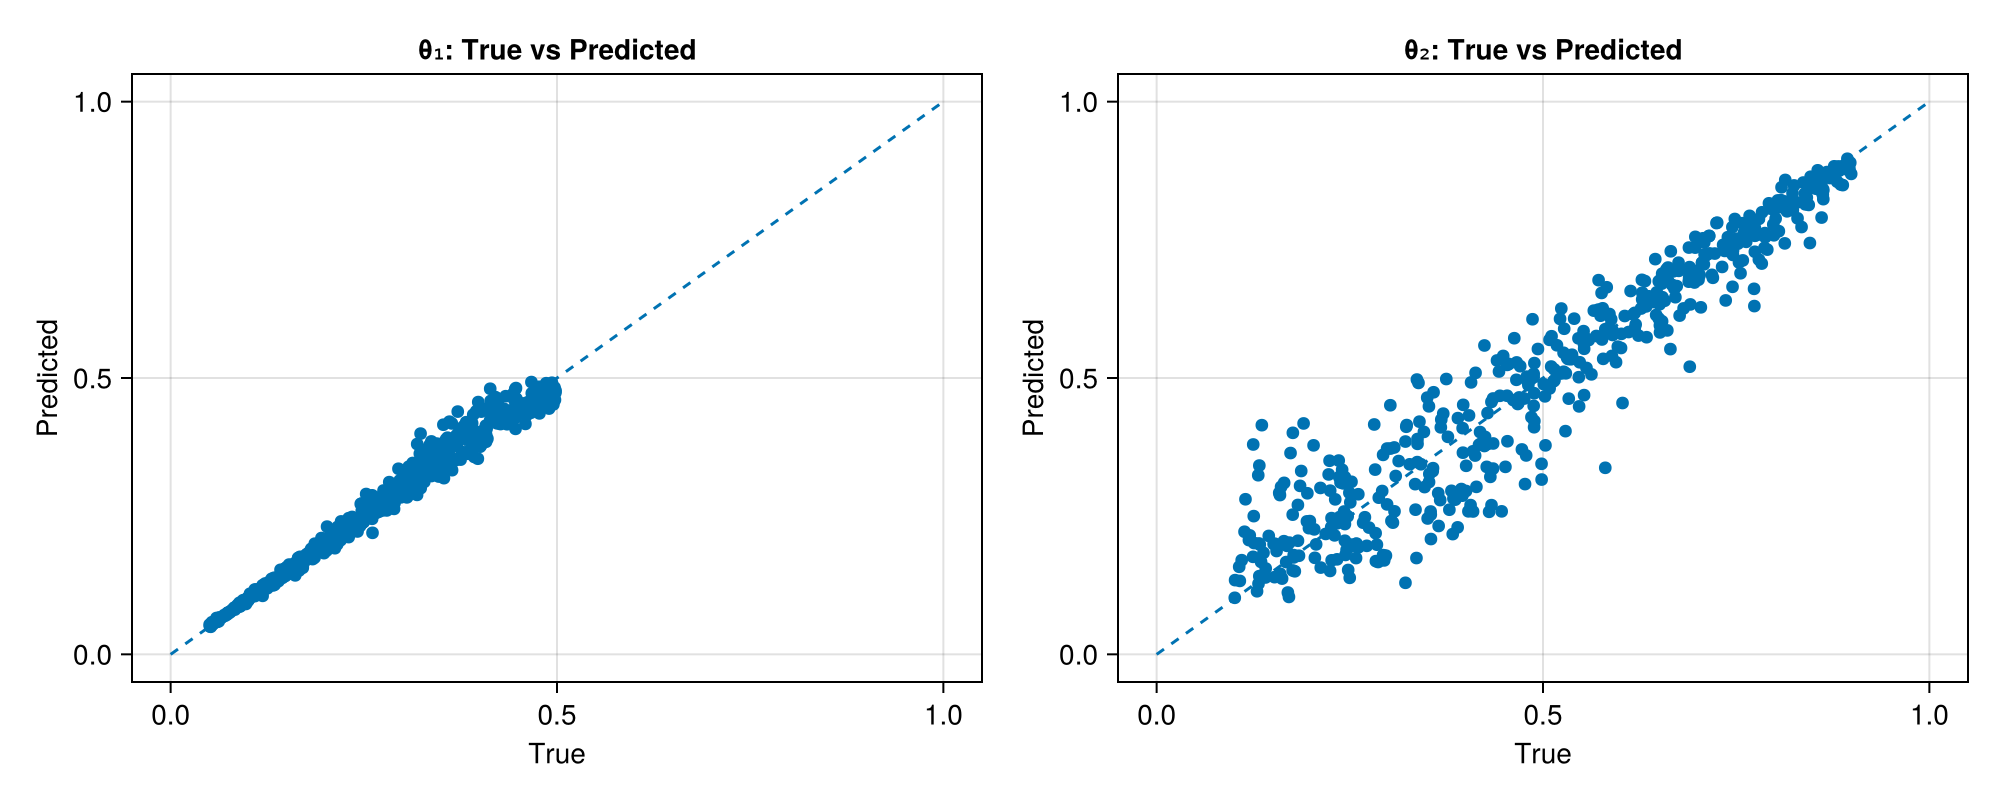

In [19]:
using CairoMakie

fig = Figure(size = (1000, 400))

# θ₁
ax1 = Axis(fig[1, 1],
    title = "θ₁: True vs Predicted",
    xlabel = "True",
    ylabel = "Predicted"
)

scatter!(ax1, theta_test[1, :], theta_pred[1, :])
lines!(ax1, [0, 1], [0, 1], linestyle = :dash)

# θ₂
ax2 = Axis(fig[1, 2],
    title = "θ₂: True vs Predicted",
    xlabel = "True",
    ylabel = "Predicted"
)

scatter!(ax2, theta_test[2, :], theta_pred[2, :])
lines!(ax2, [0, 1], [0, 1], linestyle = :dash)

fig

## Step 8: Built-in Assessment using NeuralEstimators

In addition to the manual evaluation, we use the built-in `assess` function from `NeuralEstimators.jl` to obtain standardized performance metrics.

This provides:
- Bias estimation for each parameter
- Root Mean Squared Error (RMSE)
- A unified visualization based on the framework

This step ensures consistency with the official API and validates the results obtained in the previous sections.

---

### Results

The built-in assessment is consistent with the previously computed metrics:

- **Bias:**
  - θ₁ ≈ 0.0017  
  - θ₂ ≈ -0.0016  
  → Indicates very low systematic error

- **RMSE:**
  - θ₁ ≈ 0.0176  
  - θ₂ ≈ 0.0692  

These values closely match the manually computed metrics, supporting the consistency of the evaluation pipeline.

---

### Interpretation

The near-zero bias suggests that the estimator is not systematically overestimating or underestimating the parameters.

The difference in RMSE between θ₁ and θ₂ further reinforces that the spatial range parameter is easier to recover than temporal dependence in the current architecture.

Overall, the built-in assessment provides additional evidence supporting the model's reliability within the simulated setting.

## Built-in Visualization (Assessment)

We visualize the estimator performance using the built-in assessment tools from NeuralEstimators.jl.

This provides a framework-consistent visualization of the relationship between true and predicted parameters.

The assessment visualization is broadly consistent with the manual prediction diagnostics shown previously.

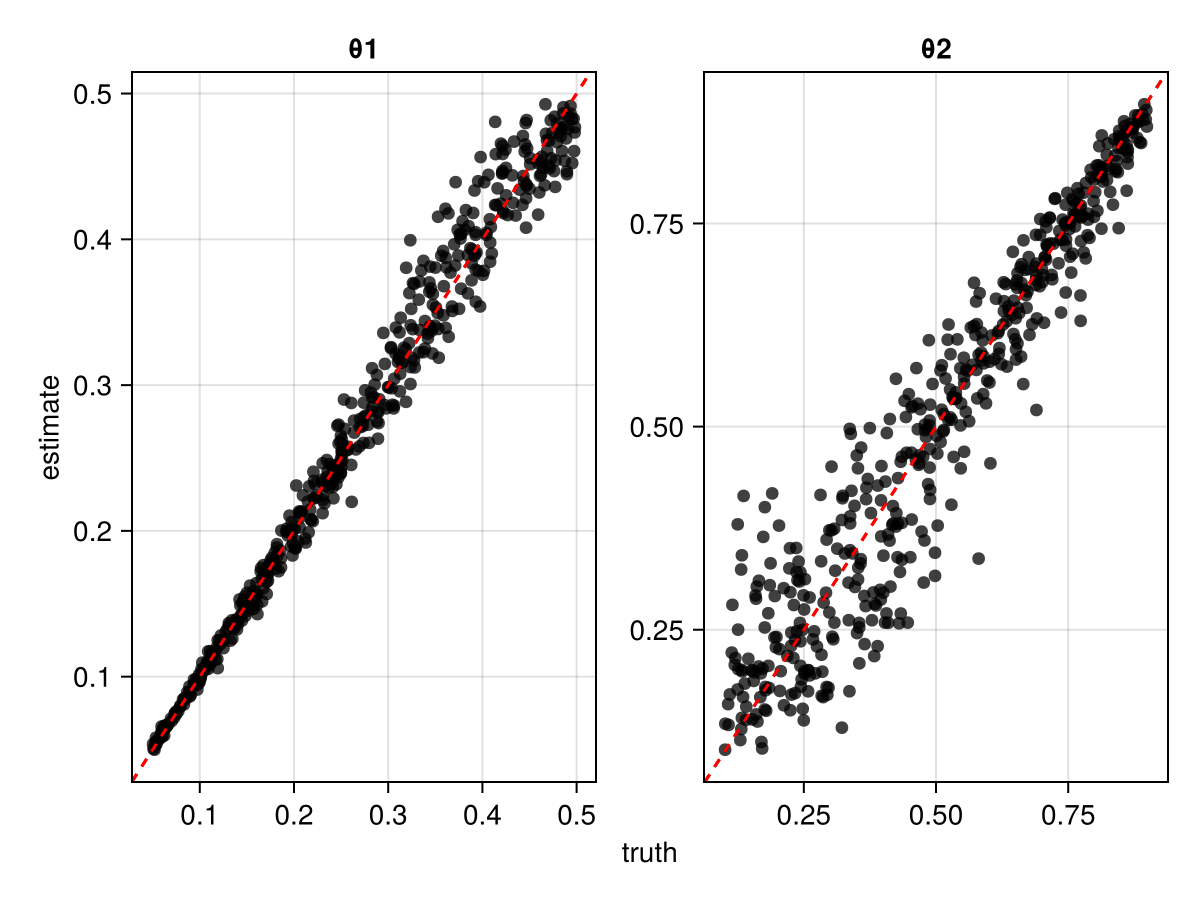

CairoMakie.Screen{IMAGE}


In [23]:
# ================================
# Built-in Visualization
# ================================

using AlgebraOfGraphics
using CairoMakie

# Generate plot
fig_assessment = AlgebraOfGraphics.plot(assessment)

# Display in notebook
display(fig_assessment)

## Saving Results

The generated figure is saved for documentation and inclusion in the project README.

In [24]:
# ================================
# Save Visualization
# ================================

# Create assets directory if it doesn't exist
mkpath("../assets")

# Save figure
save("../assets/assessment_results.png", fig_assessment)

println("✅ Figure saved to assets/assessment_results.png")

✅ Figure saved to assets/assessment_results.png


The agreement between manual and built-in evaluation provides additional support for the consistency of the implementation and the robustness of the reported results.

In [26]:
# ================================
# Save Trained Model
# ================================

using JLD2

mkpath("../models")

@save "../models/nbe_model.jld2" network

println("✅ Model saved successfully!")

✅ Model saved successfully!


## Reproducibility Note

All results reported in this notebook are reproducible from the provided simulation, preprocessing, and training pipeline.

## Author : Wejdan Majed Alharthi